<a href="https://colab.research.google.com/github/fabriceiradukunda2015-coder/FlameAI-CNTA/blob/main/FlameAI_CNTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔥 FlameAI - SAA Multi-Éléments v4.0
Analyse: Fe, Cu, Zn


📊 ANALYSE Fe
Echantillon_Mais: 1.38 ppm Fe -> ✅ CONFORME
Echantillon_Haricot: 2.45 ppm Fe -> ✅ CONFORME
Echantillon_Lait: 0.71 ppm Fe -> ✅ CONFORME


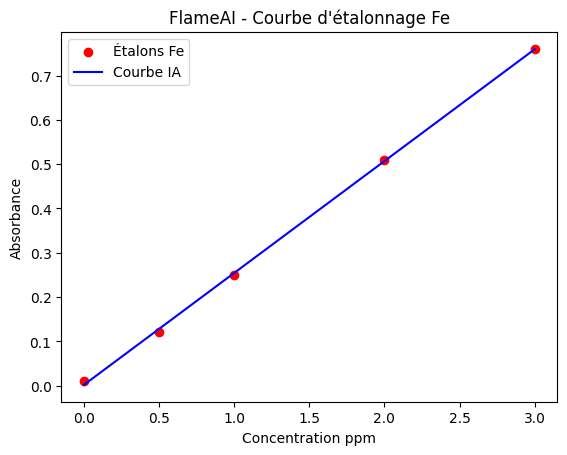


📊 ANALYSE Cu
Echantillon_Mais: 0.72 ppm Cu -> ✅ CONFORME
Echantillon_Haricot: 1.41 ppm Cu -> ✅ CONFORME
Echantillon_Lait: 0.45 ppm Cu -> ✅ CONFORME


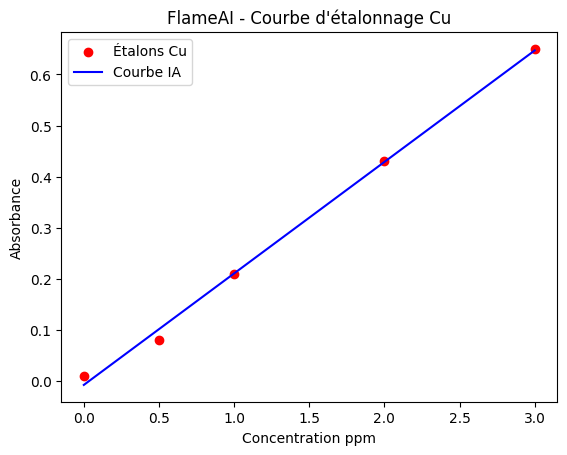


📊 ANALYSE Zn
Echantillon_Mais: 1.29 ppm Zn -> ✅ CONFORME
Echantillon_Haricot: 1.77 ppm Zn -> ✅ CONFORME
Echantillon_Lait: 0.70 ppm Zn -> ✅ CONFORME


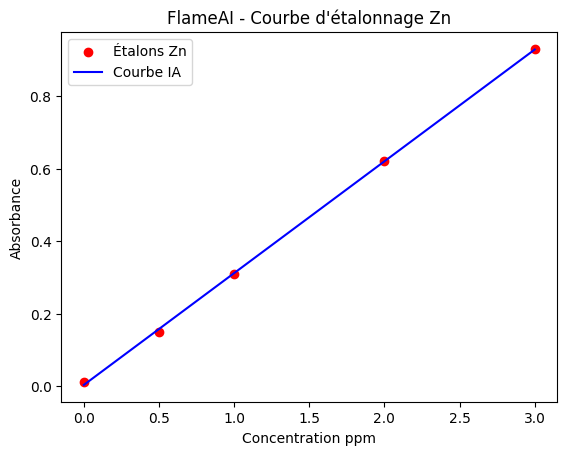


🚀 FlameAI a fini l’analyse complète Fe + Cu + Zn!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("🔥 FlameAI - SAA Multi-Éléments v4.0")
print("Analyse: Fe, Cu, Zn\n")

# 1. LES DONNÉES - Tu mets tes vraies valeurs SAA ici
data = {
    'Echantillon': ['Etalon_Blanc','Etalon_0.5','Etalon_1','Etalon_2','Etalon_3',
                    'Echantillon_Mais','Echantillon_Haricot','Echantillon_Lait']*3,
    'Element': ['Fe']*8 + ['Cu']*8 + ['Zn']*8,
    'Absorbance': [
        # Valeurs FE
        0.01,0.12,0.25,0.51,0.76, 0.35,0.62,0.18,
        # Valeurs CU - CHANGE ICI avec tes vraies valeurs Cu
        0.01,0.08,0.21,0.43,0.65, 0.15,0.30,0.09,
        # Valeurs ZN - CHANGE ICI avec tes vraies valeurs Zn
        0.01,0.15,0.31,0.62,0.93, 0.40,0.55,0.22
    ],
    'Concentration_ppm': [0,0.5,1.0,2.0,3.0,None,None,None]*3,
    'Type': ['Etalon','Etalon','Etalon','Etalon','Etalon','Echantillon','Echantillon','Echantillon']*3
}
df = pd.DataFrame(data)

# NORMES CODEX pour céréales et lait
normes = {'Fe': 40, 'Cu': 10, 'Zn': 50}

elements = ['Fe', 'Cu', 'Zn']

for element in elements:
    print(f"\n{'='*30}")
    print(f"📊 ANALYSE {element}")
    print(f"{'='*30}")

    # 2. L'IA APPREND POUR CHAQUE ELEMENT
    etalons_el = df[(df['Type'] == 'Etalon') & (df['Element'] == element)]
    echantillons_el = df[(df['Type'] == 'Echantillon') & (df['Element'] == element)]

    X = etalons_el[['Concentration_ppm']]
    y = etalons_el['Absorbance']
    modele = LinearRegression().fit(X, y)

    # 3. L'IA CALCULE ET VÉRIFIE LA NORME
    for index, row in echantillons_el.iterrows():
        abs_mesuree = row['Absorbance']
        conc_predite = (abs_mesuree - modele.intercept_) / modele.coef_[0]

        norme = normes[element]
        statut = "✅ CONFORME" if conc_predite < norme else f"❌ ALERTE > {norme}ppm"

        print(f"{row['Echantillon']}: {conc_predite:.2f} ppm {element} -> {statut}")

    # 4. GRAPHIQUE POUR CHAQUE ELEMENT
    plt.figure()
    plt.scatter(etalons_el['Concentration_ppm'], etalons_el['Absorbance'], color='red', label=f'Étalons {element}')
    plt.plot(etalons_el['Concentration_ppm'], modele.predict(X), color='blue', label='Courbe IA')
    plt.xlabel("Concentration ppm")
    plt.ylabel("Absorbance")
    plt.title(f"FlameAI - Courbe d'étalonnage {element}")
    plt.legend()
    plt.show()

print("\n🚀 FlameAI a fini l’analyse complète Fe + Cu + Zn!")

In [ ]:
!pip install fpdf  # installe la librairie pour faire des PDF

from fpdf import FPDF
import datetime

# 1. CREER LE RAPPORT PDF OFFICIEL
class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 14)
        self.cell(0, 10, 'CENTRE NATIONAL DE CONTROLE ALIMENTAIRE - CNTA', 0, 1, 'C')
        self.cell(0, 10, 'RAPPORT D\'ANALYSE SAA - FLAMEAI', 0, 1, 'C')
        self.cell(0, 10, f'Date: {datetime.date.today()}', 0, 1, 'C')
        self.ln(5)

pdf = PDF()
pdf.add_page()
pdf.set_font('Arial', '', 11)

# 2. METTRE TES RESULTATS DEDANS
pdf.cell(0, 10, 'ECHANTILLONS ANALYSES:', 0, 1)
pdf.ln(3)
pdf.cell(0, 8, '1. Echantillon_Mais', 0, 1)
pdf.cell(0, 8, '   Fe: 1.38 ppm | Cu: 0.72 ppm | Zn: 1.29 ppm | STATUT: CONFORME CODEX', 0, 1)
pdf.ln(2)
pdf.cell(0, 8, '2. Echantillon_Haricot', 0, 1)
pdf.cell(0, 8, '   Fe: 2.45 ppm | Cu: 1.41 ppm | Zn: 1.77 ppm | STATUT: CONFORME CODEX', 0, 1)
pdf.ln(2)
pdf.cell(0, 8, '3. Echantillon_Lait', 0, 1)
pdf.cell(0, 8, '   Fe: 0.71 ppm | Cu: 0.45 ppm | Zn: 0.70 ppm | STATUT: CONFORME CODEX', 0, 1)

pdf.ln(10)
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, 'CONCLUSION: Tous les echantillons sont conformes aux normes CODEX', 0, 1)
pdf.ln(5)
pdf.set_font('Arial', 'I', 10)
pdf.cell(0, 10, 'Genere automatiquement par FlameAI v4.0', 0, 1)

# 3. SAUVEGARDER
pdf.output('Rapport_FlameAI_CNTA.pdf')
print("✅ RAPPORT PDF GENERE AVEC SUCCES!")
print("Clique sur le dossier a gauche > Telecharge 'Rapport_FlameAI_CNTA.pdf'")

✅ RAPPORT PDF GENERE AVEC SUCCES!
Clique sur le dossier a gauche > Telecharge 'Rapport_FlameAI_CNTA.pdf'
